# Main Differential Equation Solver
- Units 
    - Volumes in meters^3
    - Surface Area in meters^2

In [16]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from scipy.integrate import solve_ivp

In [17]:
def get_vol_to_sa_df(path="./data/elevation-area-volume.csv"):
    df = pd.read_csv(path)
    df["elev"] = df["elev_ft_NAVD88"]
    df = df[["elev", "volume_m3", "area_m2"]]
    return df

def surface_area(volume, df):
    # Note: volume must be in m^3 and surface area will be returned in m^2
    return np.interp(volume, df["volume_m3"], df["area_m2"])

def get_vp_salinity_df(path="./data/vp-salinity.csv"):
    df = pd.read_csv(path)
    return df

def vp_reduction(salinity, df):
    return np.interp(salinity, df["salinity"], df["vp_reduction"])

def salinity(volume):
    return 1230618833073.342*(1/volume) + 171886.23798781837*(volume**(-1/3))

df_sa = get_vol_to_sa_df()

## Inflow function

In [18]:
# Precipitation
prcp = pd.read_csv("data/historical_precipitation_values.csv")

def precipitation_empirical(t, V):
    return surface_area(V, df_sa) * prcp.loc[t]["Precip"]

def precipitation(t, V):
    A, B, phi, C = 3.62510665e-04, 1.72209593e-02, 5.55109972e-01, 1.07152734e-03
    return surface_area(V, df_sa) * (A * np.sin(B * t + phi) + C)

In [19]:
def inflow(t, V):
    # function from inflow.ipynb, see file for function parameters
    seasonal_two_harmonics_human = lambda t, A1, phi1, A2, phi2, C, nu: (
    A1 * np.sin(2 * np.pi / 365 * t + phi1)
    + A2 * np.sin(2 * 2 * np.pi / 365 * t + phi2)
    + C) - (nu * t)

    params = [-28.97393599, -23.20200893, -18.43745932, 4.29250411, 45.52330359]
    return seasonal_two_harmonics_human(t, *params, nu=0.002) + precipitation(t, V)

## Outflow function

In [20]:
# Weather Functions (Simulating Seasons)
def simulate_temperature(t):
    # Simulates temperature in Celsius over a 365 day year
    # Peaks in summer (around month 7), lowest in winter
    mean_temp = 11.0
    amplitude = 15.0
    return mean_temp + amplitude * np.sin(2 * np.pi * (t - 213) / 365)

def simulate_wind_speed(t):
    # Simulates wind speed in m/s
    mean_wind = 3.0
    amplitude = 1.5
    return mean_wind + amplitude * np.sin(2 * np.pi * t / 182.5)

def calculate_vapor_pressures(T):
    RELATIVE_HUMIDITY = 0.2 # 40% average humidity
    # Magnus-Tetens formula for saturation vapor pressure (kPa)
    es = 0.611 * np.exp((17.27 * T) / (T + 237.3))
    # Actual vapor pressure
    ea = es * RELATIVE_HUMIDITY
    return es, ea

def evap_func(t, V):
    WIND_COEFF_A = 0.01     # Empirical mass transfer coefficient
    WIND_COEFF_B = 0.005    # Empirical mass transfer coefficient
    # Get current weather for month t
    T = simulate_temperature(t)
    u = simulate_wind_speed(t)

    # Calculate vapor pressures
    es, ea = calculate_vapor_pressures(T)

    # Calculate Dalton's Evaporation Rate (E)
    # E = f(wind) * (es - ea)
    wind_function = WIND_COEFF_A + WIND_COEFF_B * u
    E = wind_function * (es - ea)

    # Ensure evaporation doesn't go negative
    E = max(E, 0)

    # Calculate Area
    current_area = surface_area(V, df_sa)

    # The Final Differential
    dVdt = -E * current_area
    return dVdt

In [21]:
def outflow(t, V):
    return evap_func(t, V)

## Main Solver

In [22]:
def ode(t, V):
    return inflow(t, V) - outflow(t, V)

t_domain = (0, 7300) # Interval
y0 = np.array([18903282867.1612]) # Initial conditions

# Solve
sol = solve_ivp(ode, t_domain, y0, max_step=0.1)

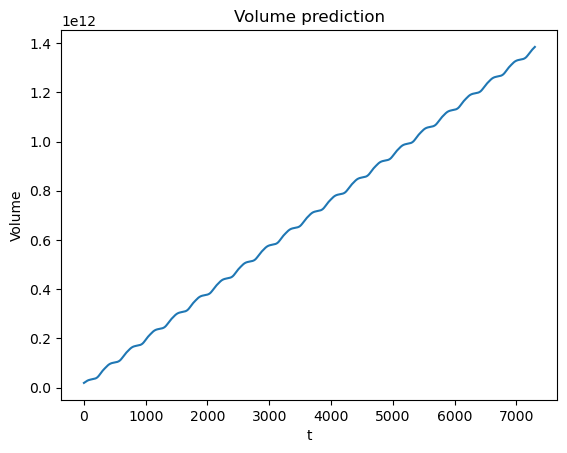

In [23]:
plt.plot(sol.t, sol.y[0])

plt.title("Volume prediction")
plt.xlabel("t")
plt.ylabel("Volume")
plt.show()